#Regresión Logistica y metódos de Regularización

Mario Vinicio Araya Baltodano

In [19]:
#Importar Librerias
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Parte 1: Regularización mediante un ejemplo polinomial

In [20]:
x1 = np.arange(-1.3, 3.5, 0.125)

In [21]:
x2 = x1 * x1
x3 = x1 * x1 * x1

In [22]:
#construccion del dataframe
w = np.column_stack((x1, x2, x3))

In [23]:
x = pd.DataFrame(w, columns=['x1', 'x2', 'x3'])

In [24]:
# Coeficientes de la función
w0 = 190
w1 = -85/3
w2 = -165
w3 = 160/3

In [25]:
#Introducir ruido a la función
noise = 200 * (random.random() - 0.5)

In [26]:
x.head()

,x1,x2,x3
0,-1.300,1.690000,-2.197000
1,-1.175,1.380625,-1.622234
2,-1.050,1.102500,-1.157625
3,-0.925,0.855625,-0.791453
4,-0.800,0.640000,-0.512000


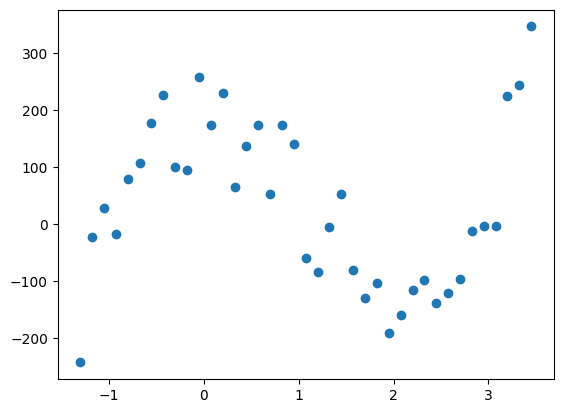

In [27]:
# Definimos nuestra variable de salida con algo de ruido para que nuestro problema
# no se reduzca simplemente a un problema de interpolación de puntos:
random.seed(1)
yreal = []
for xi in x1:
    noise = 200*(random.random() - 0.5)
    cc = w3*np.power(xi,3) + w2*np.power(xi,2) + w1*xi + w0 + noise
    yreal.append(cc)

plt.scatter(x1, yreal)
plt.show()

In [29]:
# Definamos 4 modelos: el de regresión lineal múltiple (RLM); de RLM con 
# regularización L1 (lasso); de RLM con regularización L2 (ridge) y
# RLM con regularización conjunta L1 y L2 (elastic-net):  


modelos = []
modelos.append(('LR', LinearRegression()))
modelos.append(('LASSO', Lasso(alpha=30))) 
modelos.append(('RIDGE', Ridge(alpha=30)))  
modelos.append(('EN', ElasticNet(alpha=1, l1_ratio=.5)))

In [30]:
yhat0 = []   # predicciones del modelo RLM
yhat1 = []   # predicciones del RLM con regularización L1
yhat2 = []   # predicciones del RLM con regularización L2
yhat12 = []  # predicciones del RLM con regularización L1 y L2

In [32]:
for name, model in modelos:
    # entrenamos el modelo seleccionado y obtenemos sus predicciones:
    print("%s:" % name)

    mm = model.fit(x, np.ravel(yreal))
    yhat = mm.predict(x)

    print(mm.intercept_)   # por si deseas conocer w0.
    print(mm.coef_)       # despleguemos los pesos obtenidos

    if name == 'LR':
        yhat0.append(yhat)
    elif name == 'LASSO':
        yhat1.append(yhat)
    elif name == 'RIDGE':
        yhat2.append(yhat)
    else:
        yhat12.append(yhat)

LR:
194.91638384474894
[ -40.14979812 -179.70350006   58.72754395]
LASSO:
117.13069427863516
[  -0.         -102.25253563   31.42721669]
RIDGE:
88.97294849574075
[-27.51573296 -61.84734688  22.38804271]
EN:
105.48167999947975
[-32.10655264 -79.34645456  28.06434904]


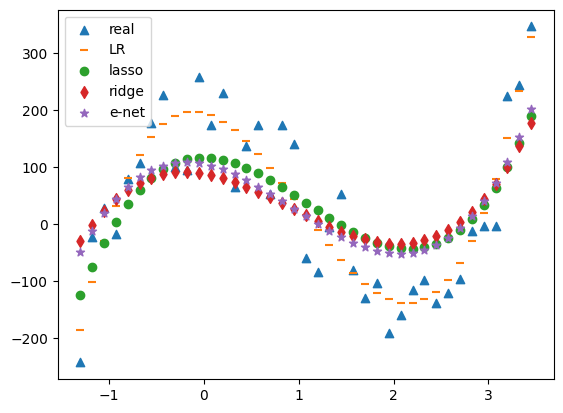

In [33]:
plt.scatter(x1, np.ravel(yreal), marker='^', label='real')  

 

plt.scatter(x1, np.ravel(yhat0), marker='_', label='LR')  

plt.scatter(x1, np.ravel(yhat1), marker='o', label='lasso')  

plt.scatter(x1, np.ravel(yhat2), marker='d', label='ridge')  

plt.scatter(x1, np.ravel(yhat12), marker='*', label='e-net')

 

plt.legend(loc=2)

plt.show()